In [1]:
from sklearn.preprocessing import scale
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline

iris = load_iris()
# 더 편리한 데이터 핸들링을 위해 DataFrame으로 변환
irisDF = pd.DataFrame(data=iris.data, columns=['sepal_length', 'sepal_width', 'petal_length', 'petal_width'])
print(irisDF.head(3))

   sepal_length  sepal_width  petal_length  petal_width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2


In [2]:
# KMeans 객체를 생성하고 군집화 수행
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, random_state=0)
kmeans.fit(irisDF)

print(kmeans.labels_)

# 실제 타깃값과 군집화 결과를 비교하기 위해 칼럼 추가
irisDF['target'] = iris.target
irisDF['cluster'] = kmeans.labels_

# target과 cluster 기준으로 그룹화하여 개수 확인
iris_result = irisDF.groupby(['target', 'cluster'])['sepal_length'].count()
print(iris_result)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 0 2 2 2 2
 2 2 0 0 2 2 2 2 0 2 0 2 0 2 2 0 0 2 2 2 2 2 0 2 2 2 2 0 2 2 2 0 2 2 2 0 2
 2 0]
target  cluster
0       1          50
1       0          47
        2           3
2       0          14
        2          36
Name: sepal_length, dtype: int64


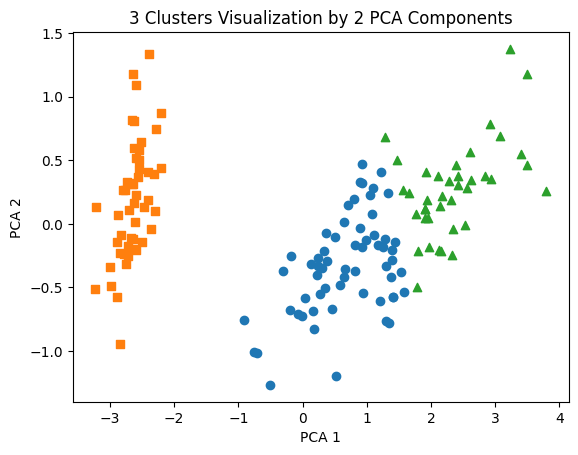

In [3]:
from sklearn.decomposition import PCA

# 2차원으로 차원 축소
pca = PCA(n_components=2)
pca_transformed = pca.fit_transform(iris.data)

irisDF['pca_x'] = pca_transformed[:, 0]
irisDF['pca_y'] = pca_transformed[:, 1]

# 군집 값이 0, 1, 2인 경우마다 별도의 인덱스로 추출
marker0_ind = irisDF[irisDF['cluster']==0].index
marker1_ind = irisDF[irisDF['cluster']==1].index
marker2_ind = irisDF[irisDF['cluster']==2].index

# 각 군집 레벨의 pca_x, pca_y 값 추출, o, s, ^로 마커 표시
plt.scatter(x=irisDF.loc[marker0_ind, 'pca_x'], y=irisDF.loc[marker0_ind, 'pca_y'], marker='o')
plt.scatter(x=irisDF.loc[marker1_ind, 'pca_x'], y=irisDF.loc[marker1_ind, 'pca_y'], marker='s')
plt.scatter(x=irisDF.loc[marker2_ind, 'pca_x'], y=irisDF.loc[marker2_ind, 'pca_y'], marker='^')

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('3 Clusters Visualization by 2 PCA Components')
plt.show()

(200, 2) (200,)
[0 1 2] [67 67 66]
       ftr1      ftr2  target
0 -1.692427  3.622025       2
1  0.697940  4.428867       0
2  1.100228  4.606317       0


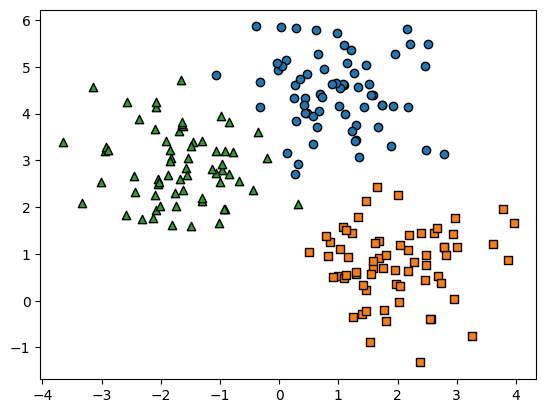

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import pandas as pd
%matplotlib inline

# 가상 데이터 세트 생성
X, y = make_blobs(n_samples=200, n_features=2, centers=3, cluster_std=0.8, random_state=0)
print(X.shape, y.shape)

# y target 값의 분포를 확인
unique, counts = np.unique(y, return_counts=True)
print(unique, counts)

# DataFrame으로 변환
clusterDF = pd.DataFrame(data=X, columns=['ftr1', 'ftr2'])
clusterDF['target'] = y
print(clusterDF.head(3))

target_list = np.unique(y)
# 각 타깃별 산점도의 마커 값
markers=['o', 's', '^', 'P', 'D', 'H', 'x']

# target 값에 따라 마커를 다르게 하여 산점도 시각화
for target in target_list:
    target_cluster = clusterDF[clusterDF['target']==target]
    plt.scatter(x=target_cluster['ftr1'], y=target_cluster['ftr2'], edgecolor='k', marker=markers[target])

plt.show()

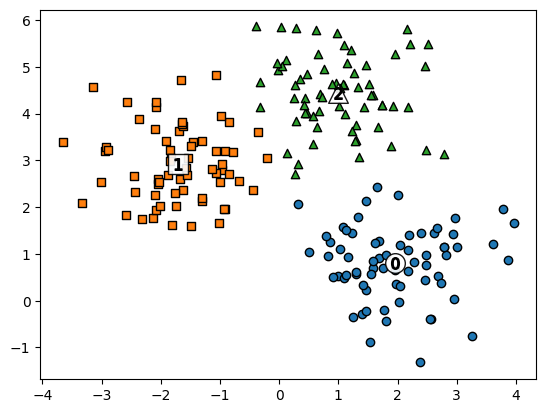

target  kmeans_label
0       2               66
        1                1
1       0               67
2       1               65
        0                1
Name: count, dtype: int64


In [5]:
# KMeans 객체를 이용해 X 데이터를 K-Means 클러스터링 수행
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=200, random_state=0)
cluster_labels = kmeans.fit_predict(X)
clusterDF['kmeans_label'] = cluster_labels

# 개별 클러스터의 중심 위치 좌표 시각화를 위해 추출
centers = kmeans.cluster_centers_
unique_labels = np.unique(cluster_labels)
markers=['o', 's', '^', 'P', 'D', 'H', 'x']

# 군집된 label 유형별로 iteration 하면서 marker 별로 scatter plot 수행
for label in unique_labels:
    label_cluster = clusterDF[clusterDF['kmeans_label']==label]
    center_x_y = centers[label]

    plt.scatter(x=label_cluster['ftr1'], y=label_cluster['ftr2'], edgecolor='k', marker=markers[label])

    # 군집별 중심 위치 좌표 시각화 (흰색 바탕에 군집 번호 표시)
    plt.scatter(x=center_x_y[0], y=center_x_y[1], s=200, color='white', alpha=0.9, edgecolor='k', marker=markers[label])
    plt.scatter(x=center_x_y[0], y=center_x_y[1], s=70, color='k', edgecolor='k', marker='$%d$' % label)

plt.show()

# 매핑된 값 확인
print(clusterDF.groupby('target')['kmeans_label'].value_counts())

In [6]:
from sklearn.preprocessing import scale
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
# 실루엣 분석 평가 지표 값을 구하기 위한 API 추가
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline

iris = load_iris()
feature_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
irisDF = pd.DataFrame(data=iris.data, columns=feature_names)

# KMeans 객체를 생성하고 군집화 수행
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, random_state=0).fit(irisDF)
irisDF['cluster'] = kmeans.labels_

# iris의 모든 개별 데이터에 실루엣 계수 값을 구함.
score_samples = silhouette_samples(iris.data, irisDF['cluster'])
print('silhouette_samples() return 값의 shape', score_samples.shape)

# irisDF에 실루엣 계수 칼럼 추가
irisDF['silhouette_coeff'] = score_samples

# 모든 데이터의 평균 실루엣 계수 값을 구함.
average_score = silhouette_score(iris.data, irisDF['cluster'])
print('붓꽃 데이터 세트 Silhouette Analysis Score: {0:.3f}'.format(average_score))

print(irisDF.head(3))

silhouette_samples() return 값의 shape (150,)
붓꽃 데이터 세트 Silhouette Analysis Score: 0.551
   sepal_length  sepal_width  petal_length  petal_width  cluster  \
0           5.1          3.5           1.4          0.2        1   
1           4.9          3.0           1.4          0.2        1   
2           4.7          3.2           1.3          0.2        1   

   silhouette_coeff  
0          0.852582  
1          0.814916  
2          0.828797  


In [7]:
# 군집별 평균 실루엣 계수 값을 확인
print(irisDF.groupby('cluster')['silhouette_coeff'].mean())

cluster
0    0.422323
1    0.797604
2    0.436842
Name: silhouette_coeff, dtype: float64


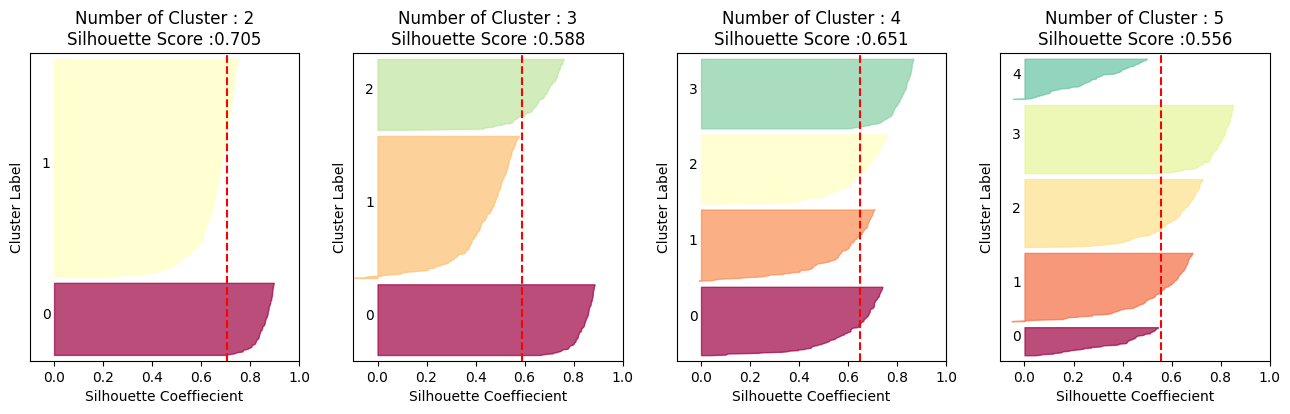

In [15]:
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

def visualize_silhouette(cluster_lists, X_features):
    # 입력값으로 n_cluster 개수들을 리스트로 받아서, 개별 n_cluster별로 실루엣 계수들을 동적으로 시각화하는 함수.

    n_cols = len(cluster_lists)

    # plt.subplots()으로 리스트에 기재된 cluster 개수만큼의 sub figures를 가지는 axs 생성
    fig, axs = plt.subplots(figsize=(4*n_cols, 4), nrows=1, ncols=n_cols)

    # for문으로 n_cluster 값들을 iteration 하면서 visualize_silhouette() 호출
    for ind, n_cluster in enumerate(cluster_lists):

        # KMeans 클러스터링 수행하고, 실루엣 스코어와 각 데이터별 실루엣 값을 구함.
        clusterer = KMeans(n_clusters = n_cluster, max_iter=500, random_state=0)
        cluster_labels = clusterer.fit_predict(X_features)

        avg_score = silhouette_score(X_features, cluster_labels)
        sample_silhouette_values = silhouette_samples(X_features, cluster_labels)

        axs[ind].set_title('Number of Cluster : '+ str(n_cluster)+'\n'+
                          'Silhouette Score :' + str(round(avg_score,3)))
        axs[ind].set_xlabel("Silhouette Coeffiecient")
        axs[ind].set_ylabel("Cluster Label")
        axs[ind].set_xlim([-0.1, 1])
        axs[ind].set_ylim([0, len(X_features) + (n_cluster + 1) * 10])
        axs[ind].set_yticks([]) # Clear the yaxis labels / ticks
        axs[ind].set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])

        # 클러스터링 갯수별로 fill_betweenx( )형태의 막대 그래프 표현.
        y_lower = 10
        for i in range(n_cluster):
            ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels==i]
            ith_cluster_silhouette_values.sort()

            size_cluster_i = ith_cluster_silhouette_values.shape[0]
            y_upper = y_lower + size_cluster_i

            # DeprecationWarning 해결: plt.cm.get_cmap 대신 plt.colormaps 사용
            color = plt.colormaps['Spectral'](float(i) / n_cluster)
            axs[ind].fill_betweenx(np.arange(y_lower, y_upper),
                                  0, ith_cluster_silhouette_values,
                                  facecolor=color, edgecolor=color, alpha=0.7)

            axs[ind].text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
            y_lower = y_upper + 10 # 각 클러스터 가시화를 위해 10만큼 간격을 더해줌

        axs[ind].axvline(x=avg_score, color="red", linestyle="--")

visualize_silhouette([2, 3, 4, 5], X)

In [17]:
# make_blobs를 통해 군집화를 위한 4개의 군집 중심의 500개 2차원 데이터 세트 생성
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=500, n_features=2, centers=4, cluster_std=1,
                  center_box=(-10.0, 10.0), shuffle=True, random_state=1)

In [18]:
from sklearn.datasets import load_iris

iris = load_iris()

In [19]:
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.cluster import MeanShift

# 가상 데이터 생성
X, y = make_blobs(n_samples=200, n_features=2, centers=3, cluster_std=0.7, random_state=0)

# bandwidth가 0.8일 때
meanshift = MeanShift(bandwidth=0.8)
cluster_labels = meanshift.fit_predict(X)
print('bandwidth 0.8일 때 cluster labels 유형: ', np.unique(cluster_labels))

# bandwidth를 1.0으로 높였을 때
meanshift = MeanShift(bandwidth=1.0)
cluster_labels = meanshift.fit_predict(X)
print('bandwidth 1.0일 때 cluster labels 유형: ', np.unique(cluster_labels))

bandwidth 0.8일 때 cluster labels 유형:  [0 1 2 3 4 5]
bandwidth 1.0일 때 cluster labels 유형:  [0 1 2]


In [20]:
from sklearn.cluster import estimate_bandwidth

# estimate_bandwidth()로 최적의 bandwidth 계산
bandwidth = estimate_bandwidth(X)
print('최적 bandwidth 값: ', round(bandwidth, 3))

최적 bandwidth 값:  1.816


최적 bandwidth 적용 cluster labels 유형:  [0 1 2]


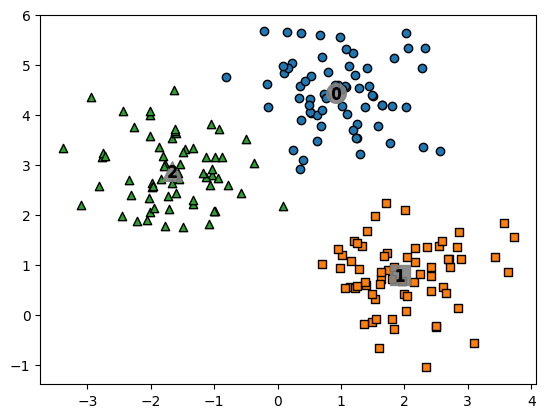

target  meanshift_label
0       0                  67
1       1                  67
2       2                  66
Name: count, dtype: int64


In [21]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

clusterDF = pd.DataFrame(data=X, columns=['ftr1', 'ftr2'])
clusterDF['target'] = y

best_bandwidth = estimate_bandwidth(X)
meanshift = MeanShift(bandwidth=best_bandwidth)
cluster_labels = meanshift.fit_predict(X)
print('최적 bandwidth 적용 cluster labels 유형: ', np.unique(cluster_labels))

clusterDF['meanshift_label'] = cluster_labels
centers = meanshift.cluster_centers_
unique_labels = np.unique(cluster_labels)
markers = ['o', 's', '^', 'x', '*']

# 군집된 label 유형별로 반복하면서 scatter plot 수행
for label in unique_labels:
    label_cluster = clusterDF[clusterDF['meanshift_label']==label]
    center_x_y = centers[label]

    # 군집별로 다른 마커로 산점도 적용
    plt.scatter(x=label_cluster['ftr1'], y=label_cluster['ftr2'], edgecolor='k', marker=markers[label])

    # 군집별 중심 표현
    plt.scatter(x=center_x_y[0], y=center_x_y[1], s=200, color='gray', alpha=0.9, marker=markers[label])
    plt.scatter(x=center_x_y[0], y=center_x_y[1], s=70, color='k', edgecolor='k', marker='$%d$' % label)

plt.show()

# 타깃값과 군집 label 비교
print(clusterDF.groupby('target')['meanshift_label'].value_counts())

In [22]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline

iris = load_iris()
feature_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

# 좀 더 편리한 데이터 Handling을 위해 DataFrame으로 변환
irisDF = pd.DataFrame(data=iris.data, columns=feature_names)
irisDF['target'] = iris.target

# GMM 군집화 수행
gmm = GaussianMixture(n_components=3, random_state=0).fit(iris.data)
gmm_cluster_labels = gmm.predict(iris.data)

# 군집화 결과를 irisDF의 'gmm_cluster' 칼럼명으로 저장
irisDF['gmm_cluster'] = gmm_cluster_labels

# target 값에 따라 gmm_cluster 값이 어떻게 매핑됐는지 확인
print('### Gaussian Mixture Clustering ###')
iris_result_gmm = irisDF.groupby(['target'])['gmm_cluster'].value_counts()
print(iris_result_gmm)

# 비교를 위한 K-Means 군집화 수행
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, random_state=0).fit(iris.data)
kmeans_cluster_labels = kmeans.predict(iris.data)
irisDF['kmeans_cluster'] = kmeans_cluster_labels

print('\n### KMeans Clustering ###')
iris_result_kmeans = irisDF.groupby(['target'])['kmeans_cluster'].value_counts()
print(iris_result_kmeans)

### Gaussian Mixture Clustering ###
target  gmm_cluster
0       1              50
1       0              45
        2               5
2       2              50
Name: count, dtype: int64

### KMeans Clustering ###
target  kmeans_cluster
0       1                 50
1       0                 47
        2                  3
2       2                 36
        0                 14
Name: count, dtype: int64


In [23]:
from sklearn.datasets import make_blobs

# make_blobs()로 300개의 데이터 세트, 3개의 군집 세트 생성
X, y = make_blobs(n_samples=300, n_features=2, centers=3, cluster_std=0.5, random_state=0)

# 길게 늘어난 타원형의 데이터 세트를 생성하기 위해 변환
transformation = [[0.60834549, -0.63667341], [-0.40887718, 0.85253229]]
X_aniso = np.dot(X, transformation)

# DataFrame으로 저장
clusterDF = pd.DataFrame(data=X_aniso, columns=['ftr1', 'ftr2'])
clusterDF['target'] = y

# 주의: visualize_cluster_plot 함수는 부록 소스 코드로 별도 선언 필요 (주석 처리)
# visualize_cluster_plot(None, clusterDF, 'target', iscenter=False)

# 3개의 군집 기반 K-Means 적용
kmeans = KMeans(3, random_state=0)
kmeans_label = kmeans.fit_predict(X_aniso)
clusterDF['kmeans_label'] = kmeans_label
# visualize_cluster_plot(kmeans, clusterDF, 'kmeans_label', iscenter=True)

# 3개의 n_components 기반 GMM 적용
gmm = GaussianMixture(n_components=3, random_state=0)
gmm_label = gmm.fit(X_aniso).predict(X_aniso)
clusterDF['gmm_label'] = gmm_label
# visualize_cluster_plot(gmm, clusterDF, 'gmm_label', iscenter=False)

print('### KMeans Clustering ###')
print(clusterDF.groupby('target')['kmeans_label'].value_counts())

print('\n### Gaussian Mixture Clustering ###')
print(clusterDF.groupby('target')['gmm_label'].value_counts())

### KMeans Clustering ###
target  kmeans_label
0       2                73
        0                27
1       1               100
2       0                86
        2                14
Name: count, dtype: int64

### Gaussian Mixture Clustering ###
target  gmm_label
0       2            100
1       1            100
2       0            100
Name: count, dtype: int64


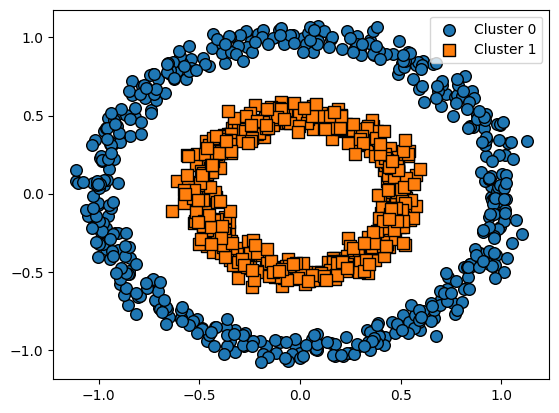

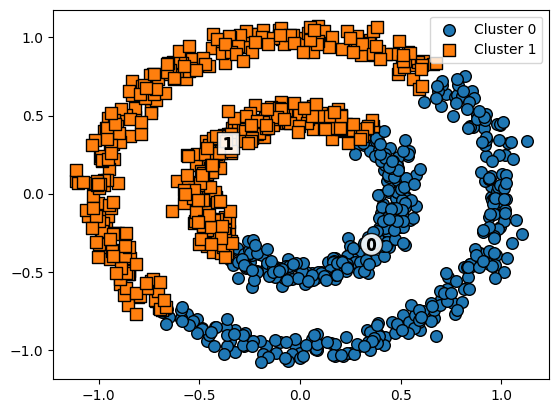

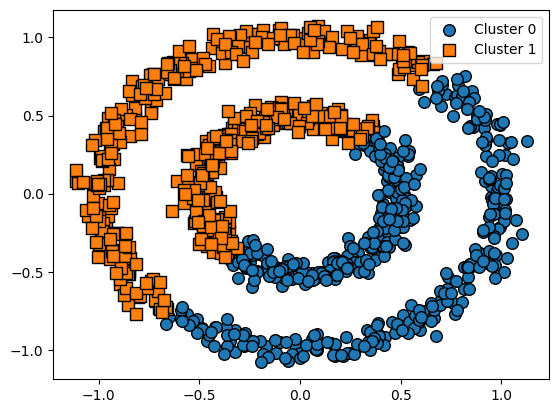

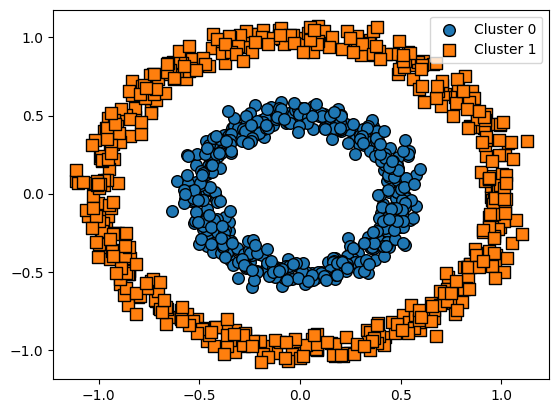

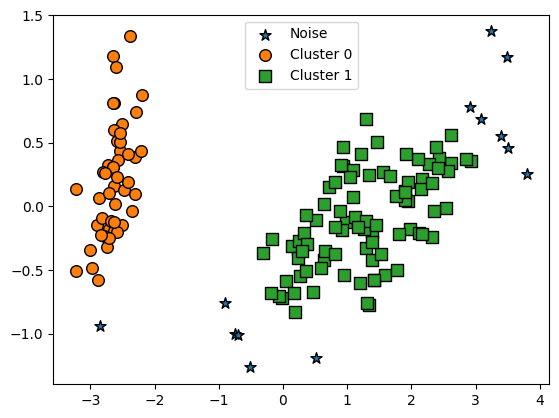

In [30]:
from sklearn.datasets import load_iris
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture


def visualize_cluster_plot(clusterobj, dataframe, label_name, iscenter=False):
    if iscenter: # K-Means 또는 Meanshift인 경우 군집 중심 시각화
        centers = clusterobj.cluster_centers_

    unique_labels = np.unique(dataframe[label_name].values)
    markers=['o', 's', '^', 'x', '*']
    isNoise=False

    for label in unique_labels:
        label_cluster = dataframe[dataframe[label_name]==label]
        if label == -1: # DBSCAN에서 노이즈인 경우
            cluster_legend = 'Noise'
            isNoise=True
        else:
            cluster_legend = 'Cluster '+str(label)

        plt.scatter(x=label_cluster['ftr1'], y=label_cluster['ftr2'], s=70,
                    edgecolor='k', marker=markers[label], label=cluster_legend)

        if iscenter: # 군집 중심 시각화
            center_x_y = centers[label]
            plt.scatter(x=center_x_y[0], y=center_x_y[1], s=250, color='white',
                        alpha=0.9, edgecolor='k', marker=markers[label])
            plt.scatter(x=center_x_y[0], y=center_x_y[1], s=70, color='k',
                        edgecolor='k', marker='$%d$' % label)
    if isNoise: # 노이즈인 경우 범례를 따로 표시
        legend_loc='upper center'
    else: legend_loc='upper right'

    plt.legend(loc=legend_loc)
    plt.show()

# 데이터 로드 및 DataFrame 변환
iris = load_iris()
irisDF = pd.DataFrame(data=iris.data, columns=['sepal_length', 'sepal_width', 'petal_length', 'petal_width'])

# 기본 DBSCAN 적용 (이전 예제 기준)
dbscan = DBSCAN(eps=0.6, min_samples=8, metric='euclidean')
dbscan_labels = dbscan.fit_predict(iris.data)
irisDF['dbscan_cluster'] = dbscan_labels
irisDF['target'] = iris.target

# 2차원으로 시각화하기 위해 PCA n_components=2로 피처 데이터 세트 변환
pca = PCA(n_components=2, random_state=0)
pca_transformed = pca.fit_transform(iris.data)

# visualize_cluster_plot() 함수 사용을 위해 PCA 변환값을 ftr1, ftr2 칼럼으로 생성
irisDF['ftr1'] = pca_transformed[:, 0]
irisDF['ftr2'] = pca_transformed[:, 1]

# 필요한 변수들을 다시 정의 (기존 코드의 의존성 해결)
# KMeans for irisDF
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, random_state=0)
kmeans.fit(irisDF.drop(['target', 'dbscan_cluster', 'ftr1', 'ftr2'], axis=1))
irisDF['kmeans_cluster'] = kmeans.labels_

# GMM for irisDF
gmm = GaussianMixture(n_components=3, random_state=0).fit(iris.data)
irisDF['gmm_cluster'] = gmm.predict(iris.data)

# Assuming clusterDF refers to the DataFrame from the make_blobs example, if needed. For this specific cell, it seems irisDF is the primary focus.
# If clusterDF is intended to be used, it needs to be made available from previous cells, or a new one created.
# For now, let's assume the calls to visualize_cluster_plot with 'clusterDF' were a mistake and should be 'irisDF'
# or that `clusterDF` should contain the data from a previous make_blobs call.

# To make this cell self-contained for the visualization, let's assume `clusterDF` (from `make_circles` example)
# and `kmeans`, `gmm`, `dbscan` objects based on that `clusterDF` (from `make_circles` example) need to be defined if not already in global scope.
# Since the traceback shows NameError for `clusterDF` in the visualization call, let's re-run the `make_circles` part from cell `ifXxR18urYqt`

from sklearn.datasets import make_circles
# 원형 데이터 세트 생성
X_circles, y_circles = make_circles(n_samples=1000, shuffle=True, noise=0.05, random_state=0, factor=0.5)
clusterDF = pd.DataFrame(data=X_circles, columns=['ftr1', 'ftr2'])
clusterDF['target'] = y_circles

# KMeans로 군집화
kmeans_circles = KMeans(n_clusters=2, max_iter=1000, random_state=0)
kmeans_labels_circles = kmeans_circles.fit_predict(X_circles)
clusterDF['kmeans_cluster'] = kmeans_labels_circles

# GMM으로 군집화
gmm_circles = GaussianMixture(n_components=2, random_state=0)
gmm_label_circles = gmm_circles.fit(X_circles).predict(X_circles)
clusterDF['gmm_cluster'] = gmm_label_circles

# DBSCAN으로 군집화
dbscan_circles = DBSCAN(eps=0.2, min_samples=10, metric='euclidean')
dbscan_labels_circles = dbscan_circles.fit_predict(X_circles)
clusterDF['dbscan_cluster'] = dbscan_labels_circles



visualize_cluster_plot(None, clusterDF, 'target', iscenter=False)
visualize_cluster_plot(kmeans_circles, clusterDF, 'kmeans_cluster', iscenter=True)
visualize_cluster_plot(gmm_circles, clusterDF, 'gmm_cluster', iscenter=False)
visualize_cluster_plot(dbscan_circles, clusterDF, 'dbscan_cluster', iscenter=False)
visualize_cluster_plot(dbscan, irisDF, 'dbscan_cluster', iscenter=False)


In [31]:
# 1. eps를 0.6에서 0.8로 증가시켰을 때 (노이즈 감소)
dbscan = DBSCAN(eps=0.8, min_samples=8, metric='euclidean')
dbscan_labels = dbscan.fit_predict(iris.data)

irisDF['dbscan_cluster'] = dbscan_labels
irisDF['target'] = iris.target

print("### eps=0.8, min_samples=8 ###")
iris_result = irisDF.groupby(['target'])['dbscan_cluster'].value_counts()
print(iris_result)

# 2. eps는 0.6으로 유지하고 min_samples를 16으로 증가시켰을 때 (노이즈 증가)
dbscan = DBSCAN(eps=0.6, min_samples=16, metric='euclidean')
dbscan_labels = dbscan.fit_predict(iris.data)

irisDF['dbscan_cluster'] = dbscan_labels
irisDF['target'] = iris.target

print("\n### eps=0.6, min_samples=16 ###")
print(irisDF.groupby(['target'])['dbscan_cluster'].value_counts())

### eps=0.8, min_samples=8 ###
target  dbscan_cluster
0        0                50
1        1                50
2        1                47
        -1                 3
Name: count, dtype: int64

### eps=0.6, min_samples=16 ###
target  dbscan_cluster
0        0                48
        -1                 2
1        1                44
        -1                 6
2        1                36
        -1                14
Name: count, dtype: int64


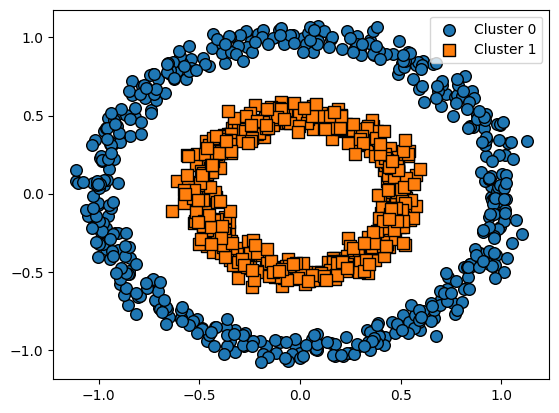

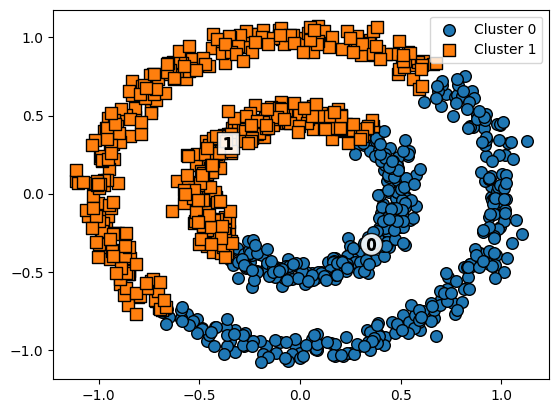

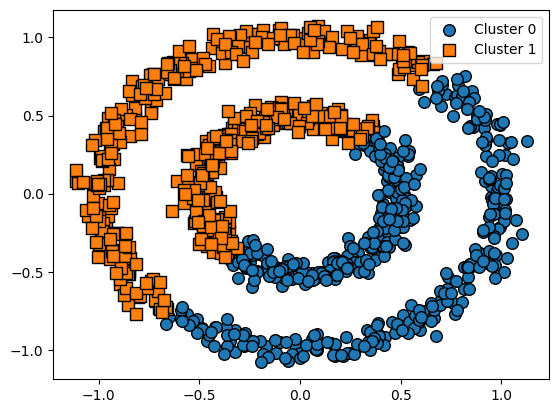

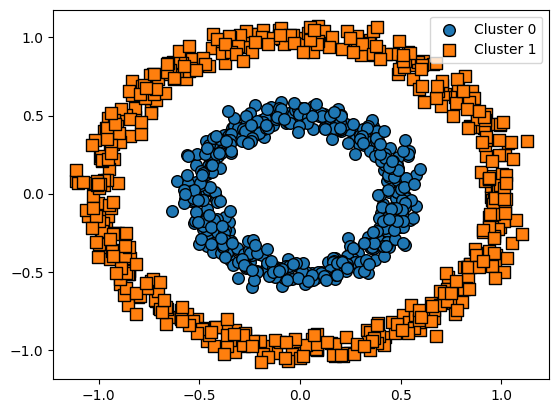

In [32]:
from sklearn.datasets import make_circles
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
import pandas as pd

# 원형 데이터 세트 생성
X, y = make_circles(n_samples=1000, shuffle=True, noise=0.05, random_state=0, factor=0.5)
clusterDF = pd.DataFrame(data=X, columns=['ftr1', 'ftr2'])
clusterDF['target'] = y

# KMeans로 군집화
kmeans = KMeans(n_clusters=2, max_iter=1000, random_state=0)
kmeans_labels = kmeans.fit_predict(X)
clusterDF['kmeans_cluster'] = kmeans_labels

# GMM으로 군집화
gmm = GaussianMixture(n_components=2, random_state=0)
gmm_label = gmm.fit(X).predict(X)
clusterDF['gmm_cluster'] = gmm_label

# DBSCAN으로 군집화
dbscan = DBSCAN(eps=0.2, min_samples=10, metric='euclidean')
dbscan_labels = dbscan.fit_predict(X)
clusterDF['dbscan_cluster'] = dbscan_labels

visualize_cluster_plot(None, clusterDF, 'target', iscenter=False)
visualize_cluster_plot(kmeans, clusterDF, 'kmeans_cluster', iscenter=True)
visualize_cluster_plot(gmm, clusterDF, 'gmm_cluster', iscenter=False)
visualize_cluster_plot(dbscan, clusterDF, 'dbscan_cluster', iscenter=False)

In [34]:
import pandas as pd
import datetime
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# 엑셀 파일 로드
retail_df = pd.read_excel(io='Online Retail.xlsx')
print(retail_df.head(3))

# 데이터 정제 작업
# 수량 및 가격이 0보다 큰 데이터, 그리고 CustomerID가 존재하는 데이터만 필터링
retail_df = retail_df[retail_df['Quantity'] > 0]
retail_df = retail_df[retail_df['UnitPrice'] > 0]
retail_df = retail_df[retail_df['CustomerID'].notnull()]

# 영국(United Kingdom) 데이터만 남기기
retail_df = retail_df[retail_df['Country'] == 'United Kingdom']
print('\n필터링 후 데이터 크기:', retail_df.shape)

# 주문 금액 칼럼 생성 및 CustomerID 형 변환
retail_df['sale_amount'] = retail_df['Quantity'] * retail_df['UnitPrice']
retail_df['CustomerID'] = retail_df['CustomerID'].astype(int)

# Top 5 고객의 주문 건수 및 주문 금액 확인
print("\n### Top 5 주문 건수 고객 ###")
print(retail_df['CustomerID'].value_counts().head(5))

print("\n### Top 5 주문 금액 고객 ###")
print(retail_df.groupby('CustomerID')['sale_amount'].sum().sort_values(ascending=False)[:5])

# 식별자 레벨 확인 (InvoiceNo + StockCode)
print("\n식별자 레벨:", retail_df.groupby(['InvoiceNo', 'StockCode'])['InvoiceNo'].count().mean())

  InvoiceNo StockCode                         Description  Quantity  \
0    536365    85123A  WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                 WHITE METAL LANTERN         6   
2    536365    84406B      CREAM CUPID HEARTS COAT HANGER         8   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  

필터링 후 데이터 크기: (354321, 8)

### Top 5 주문 건수 고객 ###
CustomerID
17841    7847
14096    5111
12748    4595
14606    2700
15311    2379
Name: count, dtype: int64

### Top 5 주문 금액 고객 ###
CustomerID
18102    259657.30
17450    194550.79
16446    168472.50
17511     91062.38
16029     81024.84
Name: sale_amount, dtype: float64

식별자 레벨: 1.028702077315023


In [36]:
# DataFrame의 groupby()의 multiple 연산을 위해 agg() 이용
aggregations = {
    'InvoiceDate': 'max',
    'InvoiceNo': 'count',
    'sale_amount': 'sum'
}
cust_df = retail_df.groupby('CustomerID').agg(aggregations)

# groupby된 결과 칼럼 값을 Recency, Frequency, Monetary로 변경
cust_df = cust_df.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'sale_amount': 'Monetary'
})
cust_df = cust_df.reset_index()
print(cust_df.head(3))

   CustomerID             Recency  Frequency  Monetary
0       12346 2011-01-18 10:01:00          1  77183.60
1       12747 2011-12-07 14:34:00        103   4196.01
2       12748 2011-12-09 12:20:00       4595  33719.73


In [37]:
import datetime as dt

# Recency는 2011년 12월 10일을 현재 날짜로 간주하고 계산
cust_df['Recency'] = dt.datetime(2011, 12, 10) - cust_df['Recency']
cust_df['Recency'] = cust_df['Recency'].apply(lambda x: x.days + 1)

print('cust_df 로우와 칼럼 건수는', cust_df.shape)
print(cust_df.head(3))

cust_df 로우와 칼럼 건수는 (3920, 4)
   CustomerID  Recency  Frequency  Monetary
0       12346      326          1  77183.60
1       12747        3        103   4196.01
2       12748        1       4595  33719.73


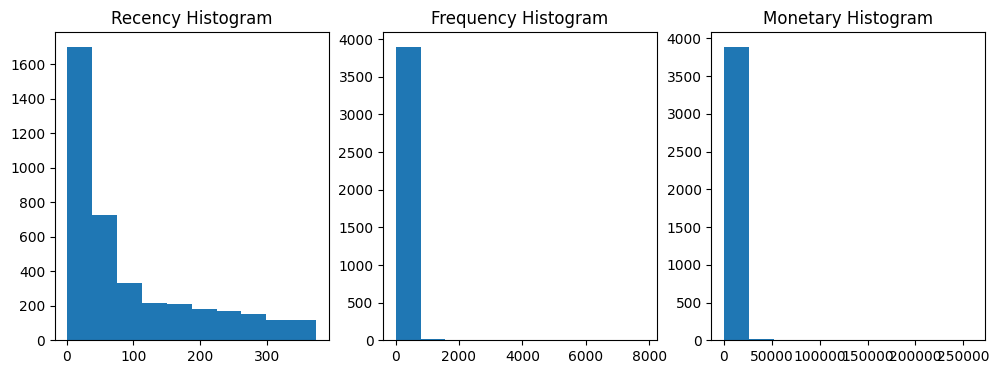

           Recency    Frequency       Monetary
count  3920.000000  3920.000000    3920.000000
mean     92.742092    90.388010    1864.385601
std      99.533485   217.808385    7482.817477
min       1.000000     1.000000       3.750000
25%      18.000000    17.000000     300.280000
50%      51.000000    41.000000     652.280000
75%     143.000000    99.250000    1576.585000
max     374.000000  7847.000000  259657.300000


In [38]:
import matplotlib.pyplot as plt
%matplotlib inline

fig, (ax1, ax2, ax3) = plt.subplots(figsize=(12, 4), nrows=1, ncols=3)

ax1.set_title('Recency Histogram')
ax1.hist(cust_df['Recency'])

ax2.set_title('Frequency Histogram')
ax2.hist(cust_df['Frequency'])

ax3.set_title('Monetary Histogram')
ax3.hist(cust_df['Monetary'])

plt.show()

# 각 칼럼의 데이터 값 백분위 확인
print(cust_df[['Recency', 'Frequency', 'Monetary']].describe())

실루엣 스코어는 : 0.576


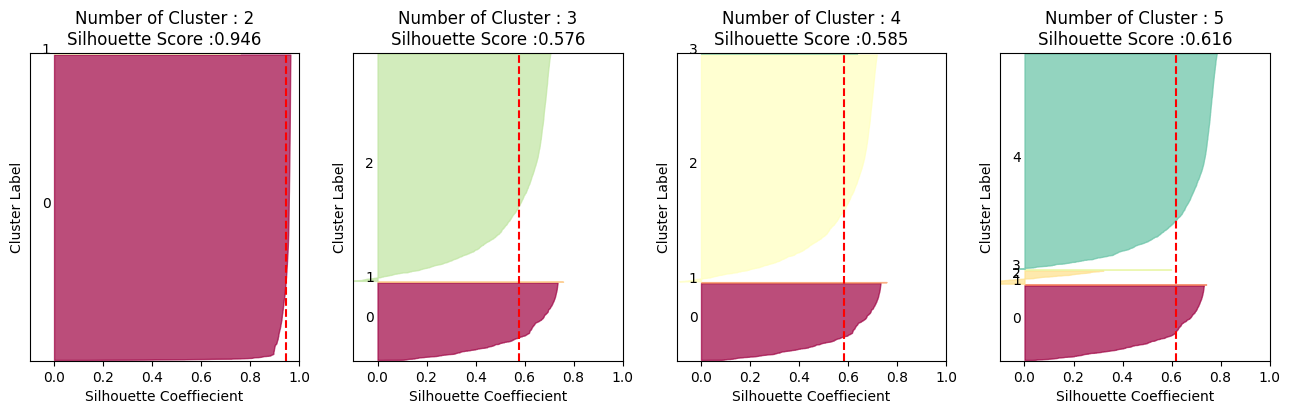

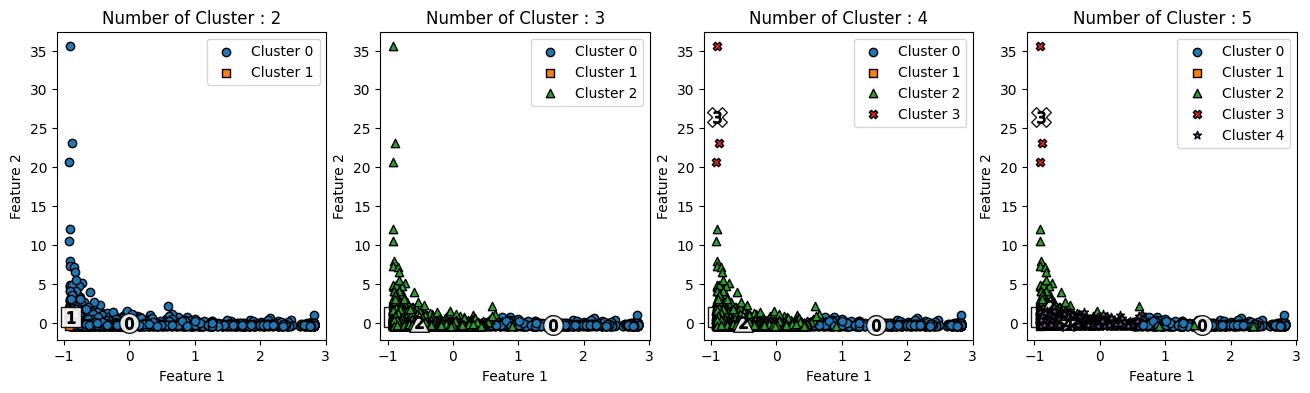

In [43]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def visualize_kmeans_plot_multi(n_clusters_list, X_features):
    # plt.subplots()으로 리스트에 기재된 cluster 개수만큼의 sub figures를 가지는 axs 생성
    n_cols = len(n_clusters_list)
    fig, axs = plt.subplots(figsize=(4*n_cols, 4), nrows=1, ncols=n_cols)

    # 입력값으로 n_cluster 개수들을 리스트로 받아서, 개별 n_cluster별로 K-Means 클러스터링을 수행하고 결과를 시각화
    for ind, n_cluster in enumerate(n_clusters_list):
        clusterer = KMeans(n_clusters = n_cluster, max_iter=500, random_state=0)
        cluster_labels = clusterer.fit_predict(X_features)
        centers = clusterer.cluster_centers_

        # 각 클러스터의 데이터와 중심을 시각화
        unique_labels = np.unique(cluster_labels)
        # 'x' 마커에 대한 UserWarning을 해결하기 위해 'x'를 'X'로 변경 (filled 'x')
        markers = ['o', 's', '^', 'X', '*']

        # axs[ind].set_xlim([-2, 2])
        # axs[ind].set_ylim([-2, 2])
        axs[ind].set_title('Number of Cluster : '+ str(n_cluster))
        axs[ind].set_xlabel('Feature 1')
        axs[ind].set_ylabel('Feature 2')

        for label in unique_labels:
            label_cluster = X_features[cluster_labels==label]
            axs[ind].scatter(x=label_cluster[:, 0], y=label_cluster[:, 1], edgecolor='k', marker=markers[label], label='Cluster '+str(label))
            axs[ind].scatter(x=centers[label, 0], y=centers[label, 1], s=200, color='white', alpha=0.9, edgecolor='k', marker=markers[label])
            axs[ind].scatter(x=centers[label, 0], y=centers[label, 1], s=70, color='k', edgecolor='k', marker='$%d$' % label)

        axs[ind].legend(loc='upper right')

    plt.show()


# 데이터 세트를 StandardScaler로 변환
X_features = cust_df[['Recency', 'Frequency', 'Monetary']].values
X_features_scaled = StandardScaler().fit_transform(X_features)

# K-평균 수행
kmeans = KMeans(n_clusters=3, random_state=0)
labels = kmeans.fit_predict(X_features_scaled)
cust_df['cluster_label'] = labels

print('실루엣 스코어는 : {0:.3f}'.format(silhouette_score(X_features_scaled, labels)))

# 부록 시각화 함수
# visualize_silhouette 함수는 이미 이전 셀에 정의되어 있으므로 여기서는 호출만 합니다.
visualize_silhouette([2, 3, 4, 5], X_features_scaled)
visualize_kmeans_plot_multi([2, 3, 4, 5], X_features_scaled)


실루엣 스코어는 : 0.303


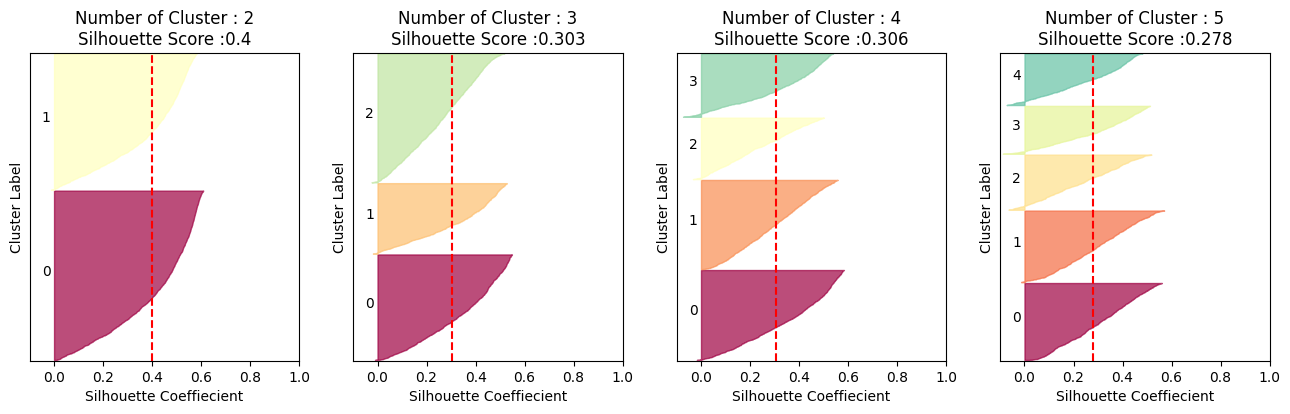

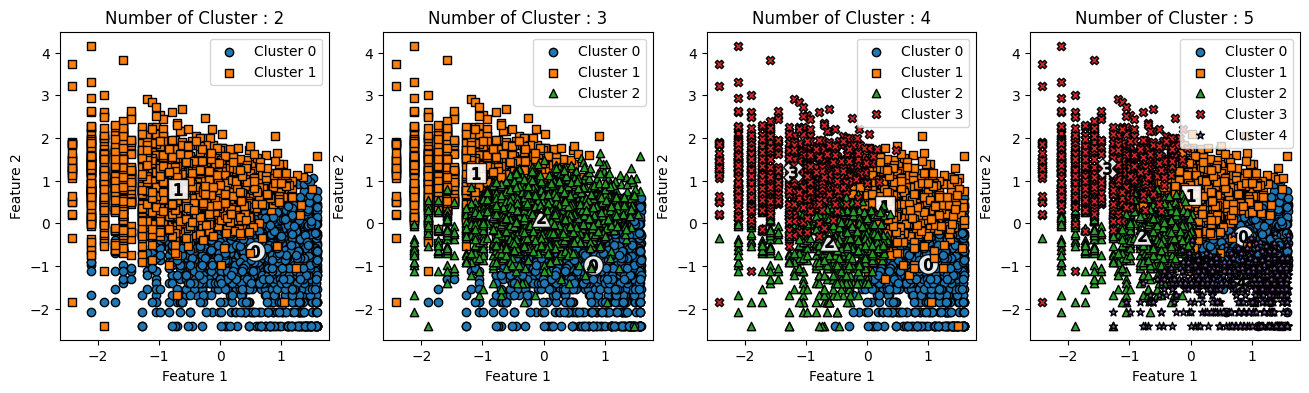

In [44]:
import numpy as np

# Recency, Frequency, Monetary 칼럼에 np.log1p()로 Log Transformation 적용
cust_df['Recency_log'] = np.log1p(cust_df['Recency'])
cust_df['Frequency_log'] = np.log1p(cust_df['Frequency'])
cust_df['Monetary_log'] = np.log1p(cust_df['Monetary'])

# Log Transformation 데이터에 StandardScaler 적용
X_features = cust_df[['Recency_log', 'Frequency_log', 'Monetary_log']].values
X_features_scaled = StandardScaler().fit_transform(X_features)

# KMeans 알고리즘 재적용
kmeans = KMeans(n_clusters=3, random_state=0)
labels = kmeans.fit_predict(X_features_scaled)
cust_df['cluster_label'] = labels

print('실루엣 스코어는 : {0:.3f}'.format(silhouette_score(X_features_scaled, labels)))

visualize_silhouette([2, 3, 4, 5], X_features_scaled)
visualize_kmeans_plot_multi([2, 3, 4, 5], X_features_scaled)
